# WWFS Birchgletscher

In [2]:
using Pkg; Pkg.activate("/scratch-3/cogier/hydraulic_barriers/")
Pkg.resolve()
using Rasters
#using Shapefile
using WhereTheWaterFlowsSubglacially, WhereTheWaterFlows
const WWFS = WhereTheWaterFlowsSubglacially
const WWF = WhereTheWaterFlows
using ArchGDAL
#using MAT
using Plots
#using GlacioTools
include("/scratch-3/cogier/GlacioTools.jl/src/Rasters_helpers.jl")
#using GLMakie
#Pkg.status()
#include("/scratch-3/cogier/WhereTheWaterFlowsSubglacially.jl/src/helpers.jl")
using CSV
using DataFrames
#import GeoStats  #GeoStats.area conflicts with the WWFS outout area
using Images
using ImageComponentAnalysis
using Statistics
include("/scratch-3/cogier/hydraulic_barriers/notebooks/functions.jl")

datadir_in = "/scratch-3/cogier/data/Birch_input"
datadir_out = "/scratch-3/cogier/data/Birch_output"


  Activating project at `/scratch-3/cogier/hydraulic_barriers`
  No Changes to `/scratch-3/cogier/hydraulic_barriers/Project.toml`
  No Changes to `/scratch-3/cogier/hydraulic_barriers/Manifest.toml`


"/scratch-3/cogier/data/Birch_output"

In [3]:
bed = Raster(joinpath(datadir_in, "B32-06_GlacierBed.tif"))
thickness = Raster(joinpath(datadir_in, "B32-06_IceThickness.tif"))

#20230823
surf_23 = Raster(joinpath(datadir_in, "B32-06_birch_20230823_dsm_is-stand_2m_lv95_ln02.tif")) #2m res
#20250523
surf_25 =  Raster(joinpath(datadir_in, "dronecam-2025-05-23T10_28_00-dem_200mmPP.tif")) # 20 cm res

surf_23_cr = crop(surf_23; to=bed) # resample bedrock to surf 23 resolution
surf_25_cr = crop(surf_25; to=bed) # resample bedrock to surf 25 resolution

# resample surf 25 to surf 23 resolution (2m)
surf_25_resamp = resample(surf_25_cr; to=surf_23_cr, method=:bilinear)

# resamp bedrock to surf 23 resolution
bed_resamp = resample(bed; to=surf_23_cr, method=:bilinear)  # downscaling bedrock to 2m resolution

┌ 699×569 Raster{Union{Missing, Float32}, 2} ┐
├────────────────────────────────────────────┴─────────────────────────── dims ┐
  ↓ X Projected{Float64} 2.63037103975e6:2.0:2.63176703975e6 ForwardOrdered Regular Intervals{Start},
  → Y Projected{Float64} 1.1394673646266414e6:-2.0:1.1383313646266414e6 ReverseOrdered Regular Intervals{Start}
├──────────────────────────────────────────────────────────────────── metadata ┤
  Metadata{Rasters.GDALsource} of Dict{String, Any} with 1 entry:
  "filepath" => "/vsimem/tmp"
├────────────────────────────────────────────────────────────────────── raster ┤
  missingval: missing
  extent: Extent(X = (2.63037103975e6, 2.63176903975e6), Y = (1.1383313646266414e6, 1.1394693646266414e6))
  crs: PROJCS["CH1903+ / LV95",GEOGCS["CH1903+",DATUM["CH1903+",SPHEROID["B...
└──────────────────────────────────────────────────────────────────────────────┘
 ↓ →        1.13947e6  1.13947e6  …  1.13834e6  1.13833e6  1.13833e6
 2.63037e6   missing    missing       miss

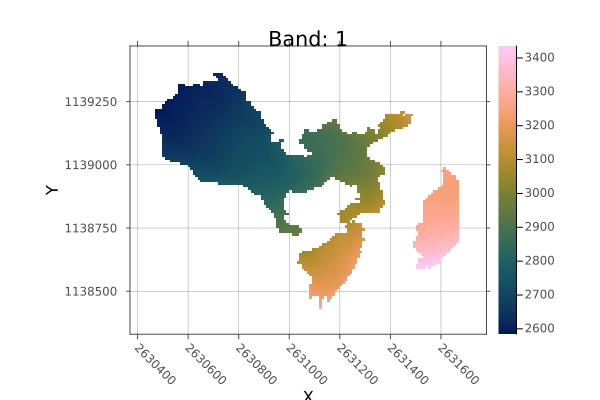

In [4]:
heatmap(bed)



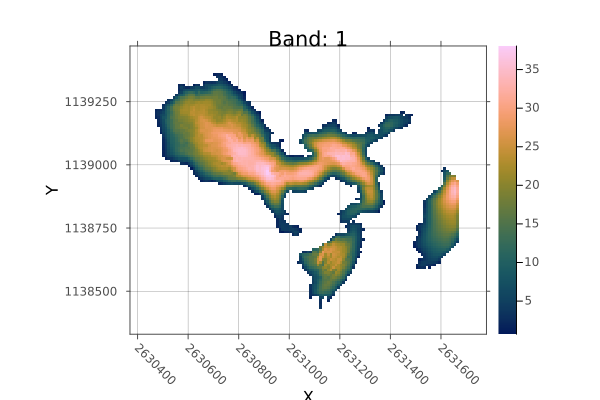

In [5]:
heatmap(thickness)

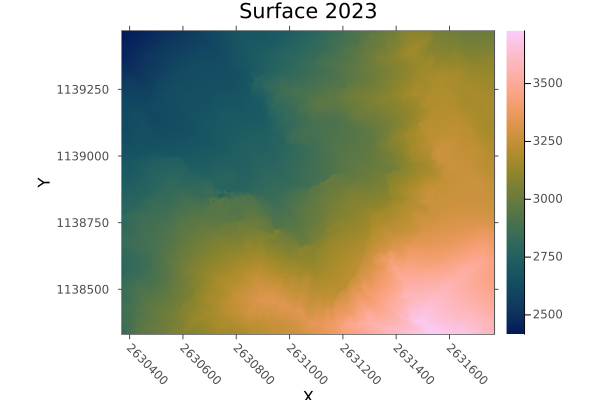

In [6]:
heatmap(surf_23_cr, title="Surface 2023")


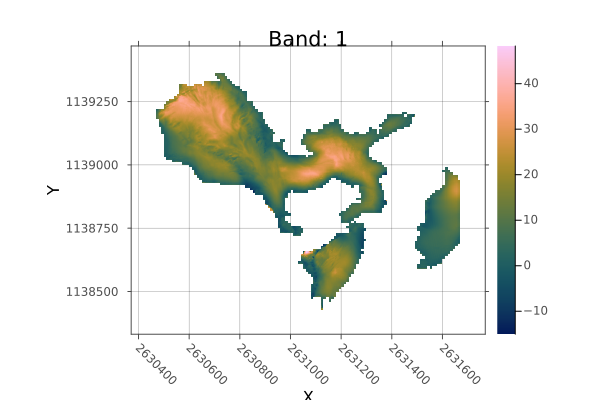

In [11]:
heatmap(surf_23_cr .- bed_resamp)